# Tourism Destination Travel Style Classification
This notebook analyzes a grounded tourism dataset and builds multiclass models to predict `travel_style`.

Dataset source:
https://www.kaggle.com/datasets/cosmox23/popular-tourist-destinations-and-their-features?utm_source=chatgpt.com

Project context:
- Used a Kaggle dataset to build on top of it: selected 200 destinations
- Used an LLM to ground the dataset to include more places/cities per destinations fetched from Kaggle: got 1200 destinations
- original destination attributes were kept as the base dataset
- additional descriptive features were added semantically with an LLM
- the target label `travel_style` was assigned semantically by the LLM from the full destination profile


In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1- Load Original Dataset from Kaggle
- sample about 200 destinations while preserving diversity
- remove the original `Type` field so a new target can be assigned later


In [142]:
# # Project-aware local path setup.
# # This works whether the notebook is launched from the repo root or from `notebooks/`.
# cwd = Path.cwd().resolve()
# PROJECT_ROOT = cwd if (cwd / "data").exists() else cwd.parent
# DATA_DIR = PROJECT_ROOT / "data"
# NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
# BACKEND_DIR = PROJECT_ROOT / "backend"

# ORIGINAL_DATA_PATH = DATA_DIR / "tourist_dests.csv"

# print(f"Working directory: {cwd}")
# print(f"Project root: {PROJECT_ROOT}")
# print(f"Data directory: {DATA_DIR}")
# print(f"Original dataset path: {ORIGINAL_DATA_PATH}")
# print(f"Exists: {ORIGINAL_DATA_PATH.exists()}")


In [143]:
# # -----------------------------
# # CONFIG
# # -----------------------------
# INPUT_PATH = ORIGINAL_DATA_PATH
# OUTPUT_PATH = DATA_DIR / "tourist_dests_200.csv"
# N_SAMPLES = 200
# RANDOM_STATE = 42

# np.random.seed(RANDOM_STATE)


# # -----------------------------
# # LOAD & CLEAN
# # -----------------------------
# df = pd.read_csv(INPUT_PATH)

# df = df.drop_duplicates()
# df.columns = df.columns.str.lower().str.strip()

# if "type" in df.columns: # to generate our own label
#     df = df.drop(columns=["type"])

# # -----------------------------
# # STRATIFIED SAMPLING
# # -----------------------------
# # idea: take equal share from each region

# stratify_col = "continent"

# n_groups = df[stratify_col].nunique()
# samples_per_group = max(1, N_SAMPLES // n_groups)

# sampled_df = (
#     df.groupby(stratify_col, group_keys=False)
#       .apply(
#           lambda x: x.sample(
#               min(len(x), samples_per_group),
#               random_state=RANDOM_STATE
#           )
#       )
# )
# sampled_df = sampled_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# # -----------------------------
# # SAVE
# # -----------------------------
# sampled_df.to_csv(OUTPUT_PATH, index=False)
# print(f"Sampled dataset saved to: {OUTPUT_PATH}")

In [144]:
# # Preview the saved sampled dataset path when running locally.
# print(f"Saved file location: {OUTPUT_PATH.resolve()}")

# 2- Load LLM-Generated Dataset
- the grounded file contains the final features used for ML
- the dataset has `1200` rows and `19` columns before the initial identifier cleanup
- the prediction target is `travel_style` with 6 classes: `Adventure`, `Relaxation`, `Culture`, `Budget`, `Luxury`, `Family`


In [145]:
# Local file path setup for the grounded dataset used in the ML section.
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "data").exists() else cwd.parent
DATA_DIR = PROJECT_ROOT / "data"

GROUNDED_DATA_PATH = DATA_DIR / "dests_1200.csv"

print(f"Grounded dataset path: {GROUNDED_DATA_PATH}")
print(f"Exists: {GROUNDED_DATA_PATH.exists()}")


Grounded dataset path: /Users/alisaralmusa/Desktop/AIE Bootcamp/Week 4 - project/data/dests_1200.csv
Exists: True


In [146]:
df = pd.read_csv(GROUNDED_DATA_PATH)
df.columns = df.columns.str.strip()
print(f"Raw dataset shape: {df.shape}")


Raw dataset shape: (1200, 19)


# 3- Data Inspection and Basic Visualization
This section verifies the dataset structure, checks data quality, explores target balance, and highlights feature patterns before modeling.


In [147]:
df.head()


,destination,country,continent,city,place_name,place_variant,avg cost (usd/day),avg_temp_year,hiking_score,beach_score,nightlife_score,culture_score,food_score,adventure_score,nature_score,safety_score,accommodation_type,terrain_type,travel_style
0,South Africa,South Africa,Africa,Kruger,Family Safari,day-trip zone,183.19,14.4,6.0,7.0,3.0,7.0,6.0,7.0,7.0,6.0,Standard Hotel,Urban-Heritage,Family
1,Japan,Japan,Asia,Kyoto,Ryokan Stays,nearby district,202.94,18.2,4.0,6.0,6.0,7.0,8.0,4.0,7.0,10.0,Resort/Apartment,Coastal,Luxury
2,Mexico,Mexico,North America,Copper Canyon,Rail and Hikes,nearby district,128.74,25.2,8.0,3.0,3.0,5.0,7.0,9.0,8.0,7.0,Guesthouse/Hostel,Mountain-Nature,Adventure
3,Australia,Australia,Oceania,Canberra,National Institutions,local experience,161.87,23.8,3.0,3.0,5.0,9.0,8.0,4.0,4.0,7.0,Standard Hotel,Urban-Heritage,Culture
4,Morocco,Morocco,Africa,Dades Valley,Canyon Routes,day-trip zone,107.87,20.5,8.0,4.0,5.0,7.0,6.0,8.0,9.0,9.0,Guesthouse/Hostel,Mountain-Nature,Adventure


In [148]:
# Drop raw identifier-style columns that are not needed for the main analysis.
columns_to_drop_after_read = ["destination", "place_name", "place_varient", "place_variant"]
existing_columns_to_drop = [col for col in columns_to_drop_after_read if col in df.columns]

df = df.drop(columns=existing_columns_to_drop)
print(f"Dropped immediately after loading: {existing_columns_to_drop}")
print(f"Dataset shape after identifier cleanup: {df.shape}")


Dropped immediately after loading: ['destination', 'place_name', 'place_variant']
Dataset shape after identifier cleanup: (1200, 16)


In [149]:
print("------- info------\n", df.info())


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             1200 non-null   str    
 1   continent           1200 non-null   str    
 2   city                1200 non-null   str    
 3   avg cost (usd/day)  1182 non-null   float64
 4   avg_temp_year       1182 non-null   float64
 5   hiking_score        1179 non-null   float64
 6   beach_score         1180 non-null   float64
 7   nightlife_score     1176 non-null   float64
 8   culture_score       1177 non-null   float64
 9   food_score          1178 non-null   float64
 10  adventure_score     1187 non-null   float64
 11  nature_score        1179 non-null   float64
 12  safety_score        1176 non-null   float64
 13  accommodation_type  1200 non-null   str    
 14  terrain_type        1200 non-null   str    
 15  travel_style        1200 non-null   str    
dtypes: float64(10), s

## Dataset Structure and Quality
This subsection summarizes schema, missing values, duplicates, and class composition.


In [150]:
# -----------------------------
# EDA SETUP
# -----------------------------
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

TARGET_COL = "travel_style"

feature_numeric_cols = [
    "avg cost (usd/day)",
    "avg_temp_year",
    "hiking_score",
    "beach_score",
    "nightlife_score",
    "culture_score",
    "food_score",
    "adventure_score",
    "nature_score",
    "safety_score",
]

feature_categorical_cols = [
    "country",
    "continent",
    "city",
    "accommodation_type",
    "terrain_type",
]

print(f"Target column: {TARGET_COL}")
print(f"Numeric feature count: {len(feature_numeric_cols)}")
print(f"Categorical feature count: {len(feature_categorical_cols)}")


Target column: travel_style
Numeric feature count: 10
Categorical feature count: 5


In [151]:
# -----------------------------
# BASIC DATA INSPECTION
# -----------------------------
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Numeric features: {len(feature_numeric_cols)}")
print(f"Categorical features: {len(feature_categorical_cols)}")
print(f"Target classes: {df[TARGET_COL].nunique()}")
print(f"Total missing values: {int(df.isna().sum().sum())}")
print(f"Duplicate rows: {int(df.duplicated().sum())}")


missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

display(missing_summary)


Dataset shape: (1200, 16)
Rows: 1200
Columns: 16
Numeric features: 10
Categorical features: 5
Target classes: 6
Total missing values: 204
Duplicate rows: 0


,missing_count,missing_percentage
nightlife_score,24,2.00
safety_score,24,2.00
culture_score,23,1.92
food_score,22,1.83
hiking_score,21,1.75
nature_score,21,1.75
beach_score,20,1.67
avg cost (usd/day),18,1.50
avg_temp_year,18,1.50
adventure_score,13,1.08


In [152]:
# -----------------------------
# CATEGORICAL FEATURE INSPECTION
# Cardinality + class percentages for each categorical feature
# -----------------------------
categorical_summary_rows = []

for col in feature_categorical_cols:
    value_counts = df[col].fillna("Missing").value_counts(dropna=False)
    value_percentages = (
        df[col].fillna("Missing").value_counts(normalize=True, dropna=False) * 100
    ).round(2)

    distribution_text = ", ".join(
        [f"{idx}: {value_counts[idx]} ({value_percentages[idx]}%)" for idx in value_counts.index]
    )

    categorical_summary_rows.append({
        "feature": col,
        "cardinality": df[col].nunique(dropna=True),
        "distribution": distribution_text,
    })

categorical_summary = pd.DataFrame(categorical_summary_rows).sort_values(
    "cardinality", ascending=False
)
display(categorical_summary)


,feature,cardinality,distribution
2,city,183,"Rotorua: 24 (2.0%), Marrakech: 19 (1.58%), Cus..."
0,country,22,"Mexico: 55 (4.58%), Australia: 55 (4.58%), Can..."
1,continent,6,"Europe: 273 (22.75%), Asia: 272 (22.67%), Afri..."
3,accommodation_type,3,"Standard Hotel: 400 (33.33%), Resort/Apartment..."
4,terrain_type,3,"Urban-Heritage: 494 (41.17%), Coastal: 469 (39..."


## Feature Distributions and Visual Patterns
This subsection explores categorical balance, numeric shape, target distribution, and feature-vs-target patterns.


In [153]:
# -----------------------------
# NUMERIC FEATURE DISTRIBUTIONS
# Mean, median, min, max, and skewness help us inspect scale and skew.
# -----------------------------
numeric_summary = (
    df[feature_numeric_cols]
    .describe()
    .T[["mean", "50%", "min", "max"]]
    .rename(columns={"50%": "median"})
)
numeric_summary["skew"] = df[feature_numeric_cols].skew(numeric_only=True)
numeric_summary = numeric_summary.sort_values("skew", key=lambda s: s.abs(), ascending=False)

display(numeric_summary.round(3))


,mean,median,min,max,skew
avg cost (usd/day),153.454,143.86,48.77,329.65,0.961
adventure_score,5.588,5.00,1.00,10.00,0.934
hiking_score,5.310,5.00,2.00,10.00,0.809
beach_score,6.179,6.00,1.00,10.00,-0.189
culture_score,6.770,7.00,3.00,10.00,0.118
food_score,7.402,7.00,5.00,10.00,0.102
avg_temp_year,18.537,18.50,2.80,34.90,-0.093
safety_score,7.456,7.00,4.00,10.00,-0.055
nature_score,6.723,7.00,3.00,10.00,0.049
nightlife_score,5.259,5.00,2.00,9.00,0.034


,count,percentage
travel_style,,
Family,200,16.67
Luxury,200,16.67
Adventure,200,16.67
Culture,200,16.67
Relaxation,200,16.67
Budget,200,16.67


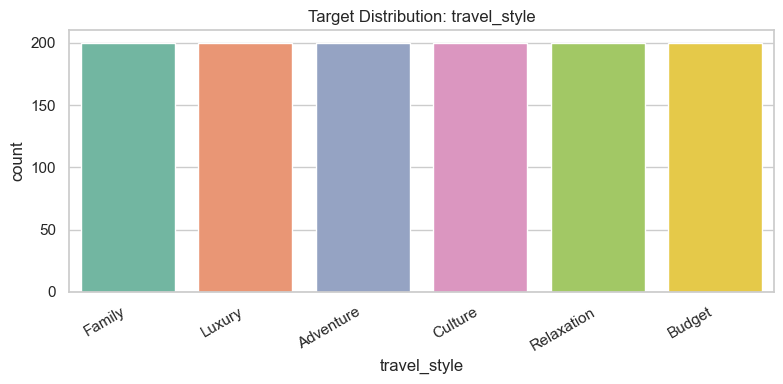

In [154]:
# -----------------------------
# TARGET DISTRIBUTION
# -----------------------------
target_distribution = df[TARGET_COL].fillna("Missing").value_counts()
target_percentages = (
    df[TARGET_COL].fillna("Missing").value_counts(normalize=True) * 100
).round(2)

display(pd.DataFrame({
    "count": target_distribution,
    "percentage": target_percentages,
}))

plot_df = df.copy()
plot_df[TARGET_COL] = plot_df[TARGET_COL].fillna("Missing")
order = plot_df[TARGET_COL].value_counts().index

plt.figure(figsize=(8, 4))
sns.countplot(
    data=plot_df,
    x=TARGET_COL,
    hue=TARGET_COL,
    order=order,
    palette="Set2",
    legend=False,
)
plt.title("Target Distribution: travel_style")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


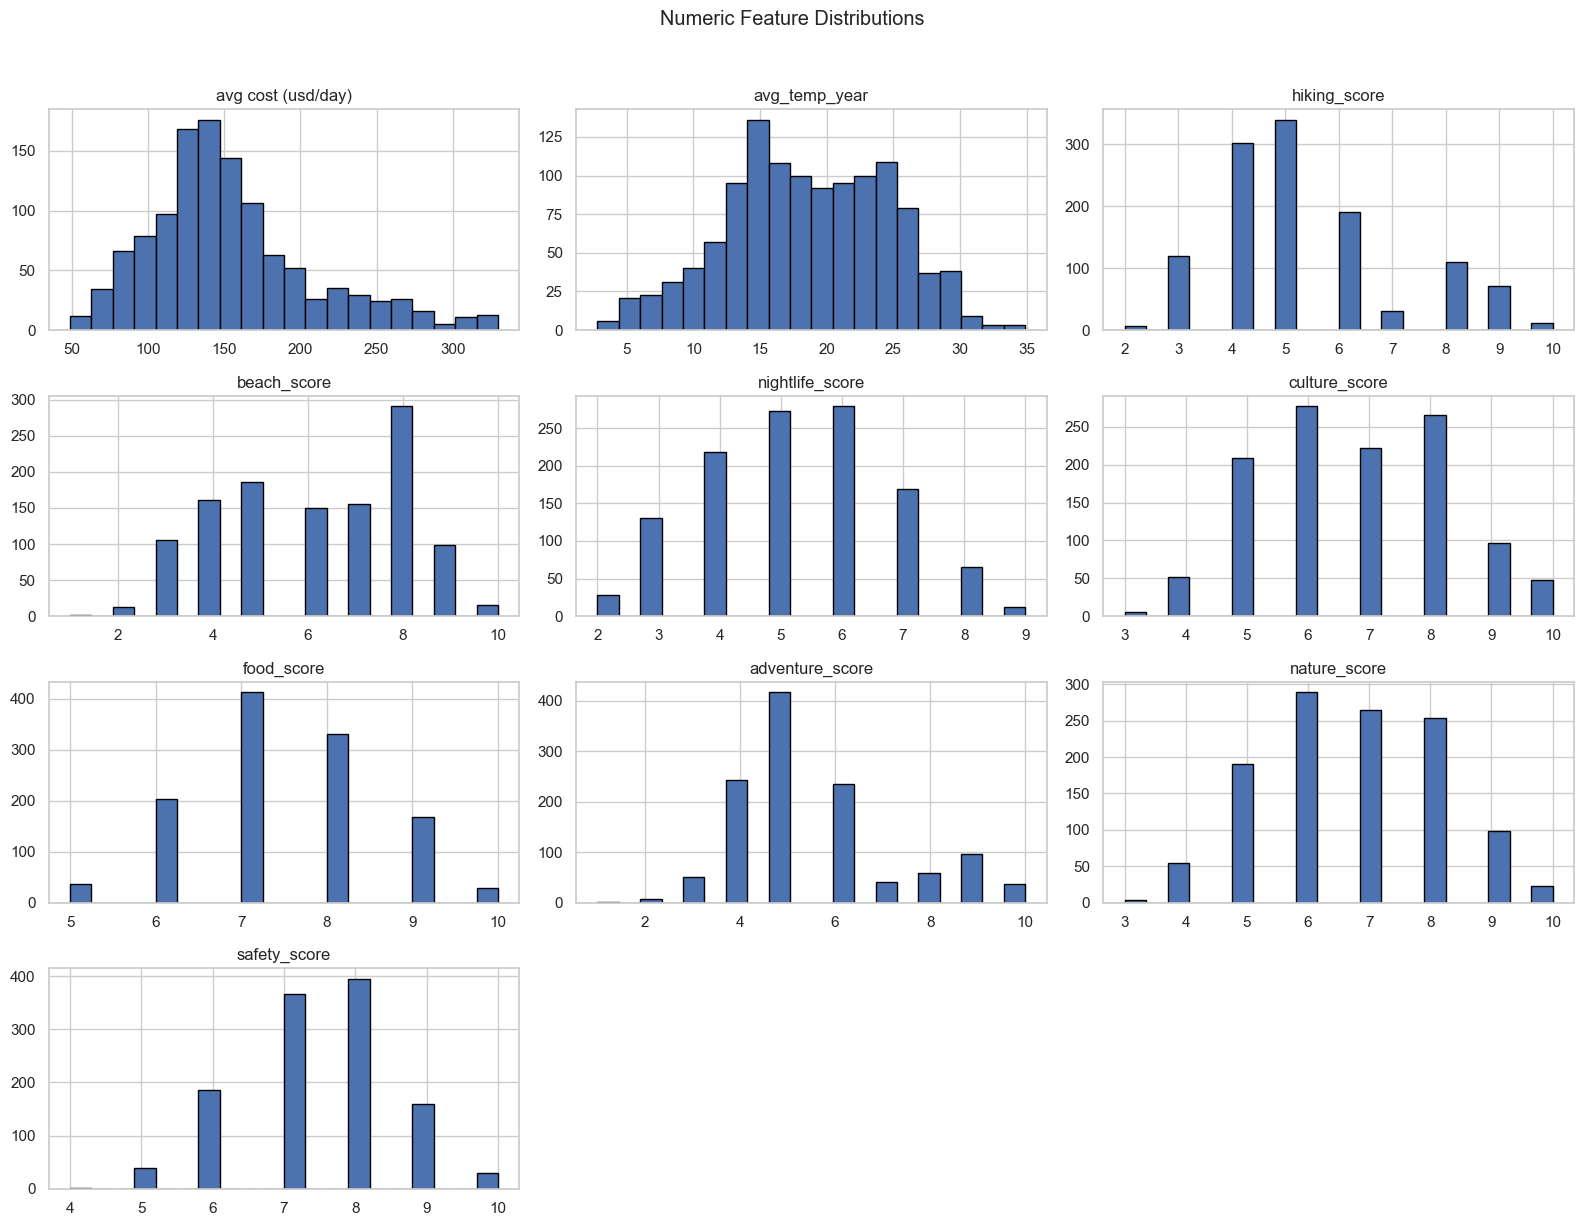

In [155]:
# -----------------------------
# HISTOGRAMS FOR NUMERIC FEATURES
# -----------------------------
if feature_numeric_cols:
    df[feature_numeric_cols].hist(figsize=(16, 12), bins=20, edgecolor="black")
    plt.suptitle("Numeric Feature Distributions", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric features available for histogram plots.")


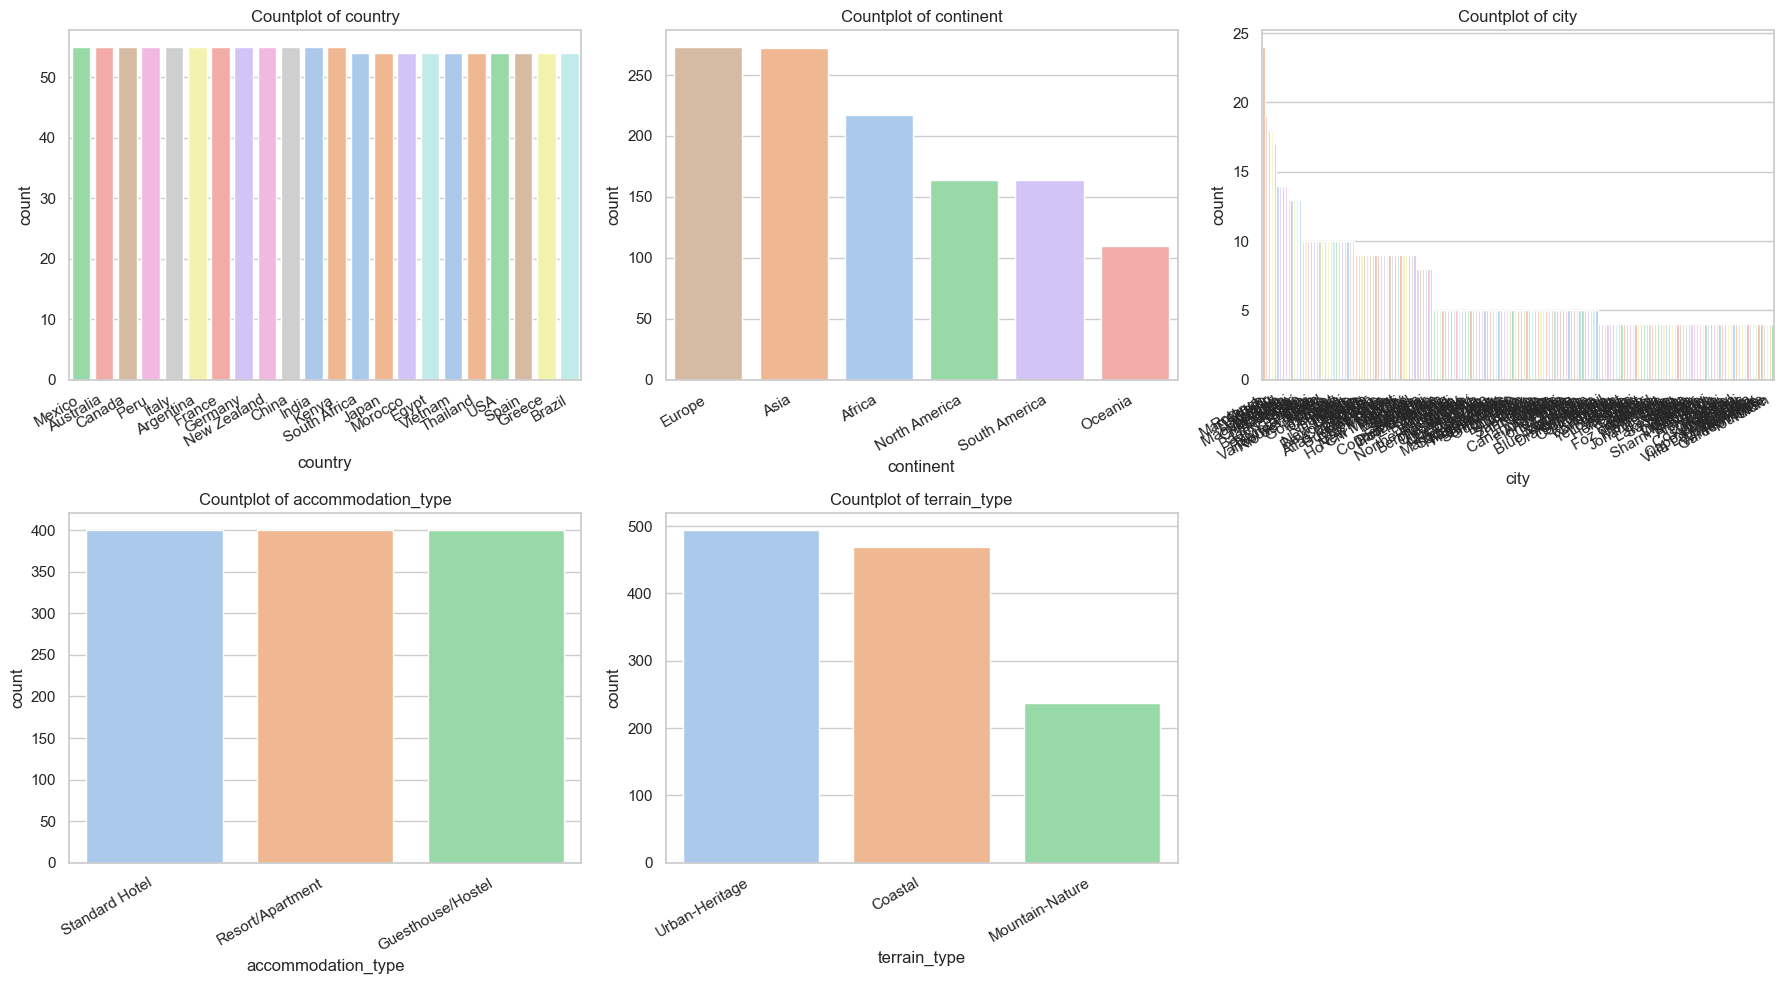

In [156]:
# -----------------------------
# COUNTPLOTS FOR CATEGORICAL FEATURES
# -----------------------------
if feature_categorical_cols:
    n_cols = 3
    n_rows = int(np.ceil(len(feature_categorical_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, feature_categorical_cols):
        plot_df = df.copy()
        plot_df[col] = plot_df[col].fillna("Missing")
        order = plot_df[col].value_counts().index

        sns.countplot(
            data=plot_df,
            x=col,
            hue=col,
            order=order,
            palette="pastel",
            legend=False,
            ax=ax,
        )
        ax.set_title(f"Countplot of {col}")
        ax.tick_params(axis="x", rotation=30)
        for label in ax.get_xticklabels():
            label.set_ha("right")

    for ax in axes[len(feature_categorical_cols):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No categorical features available for countplots.")


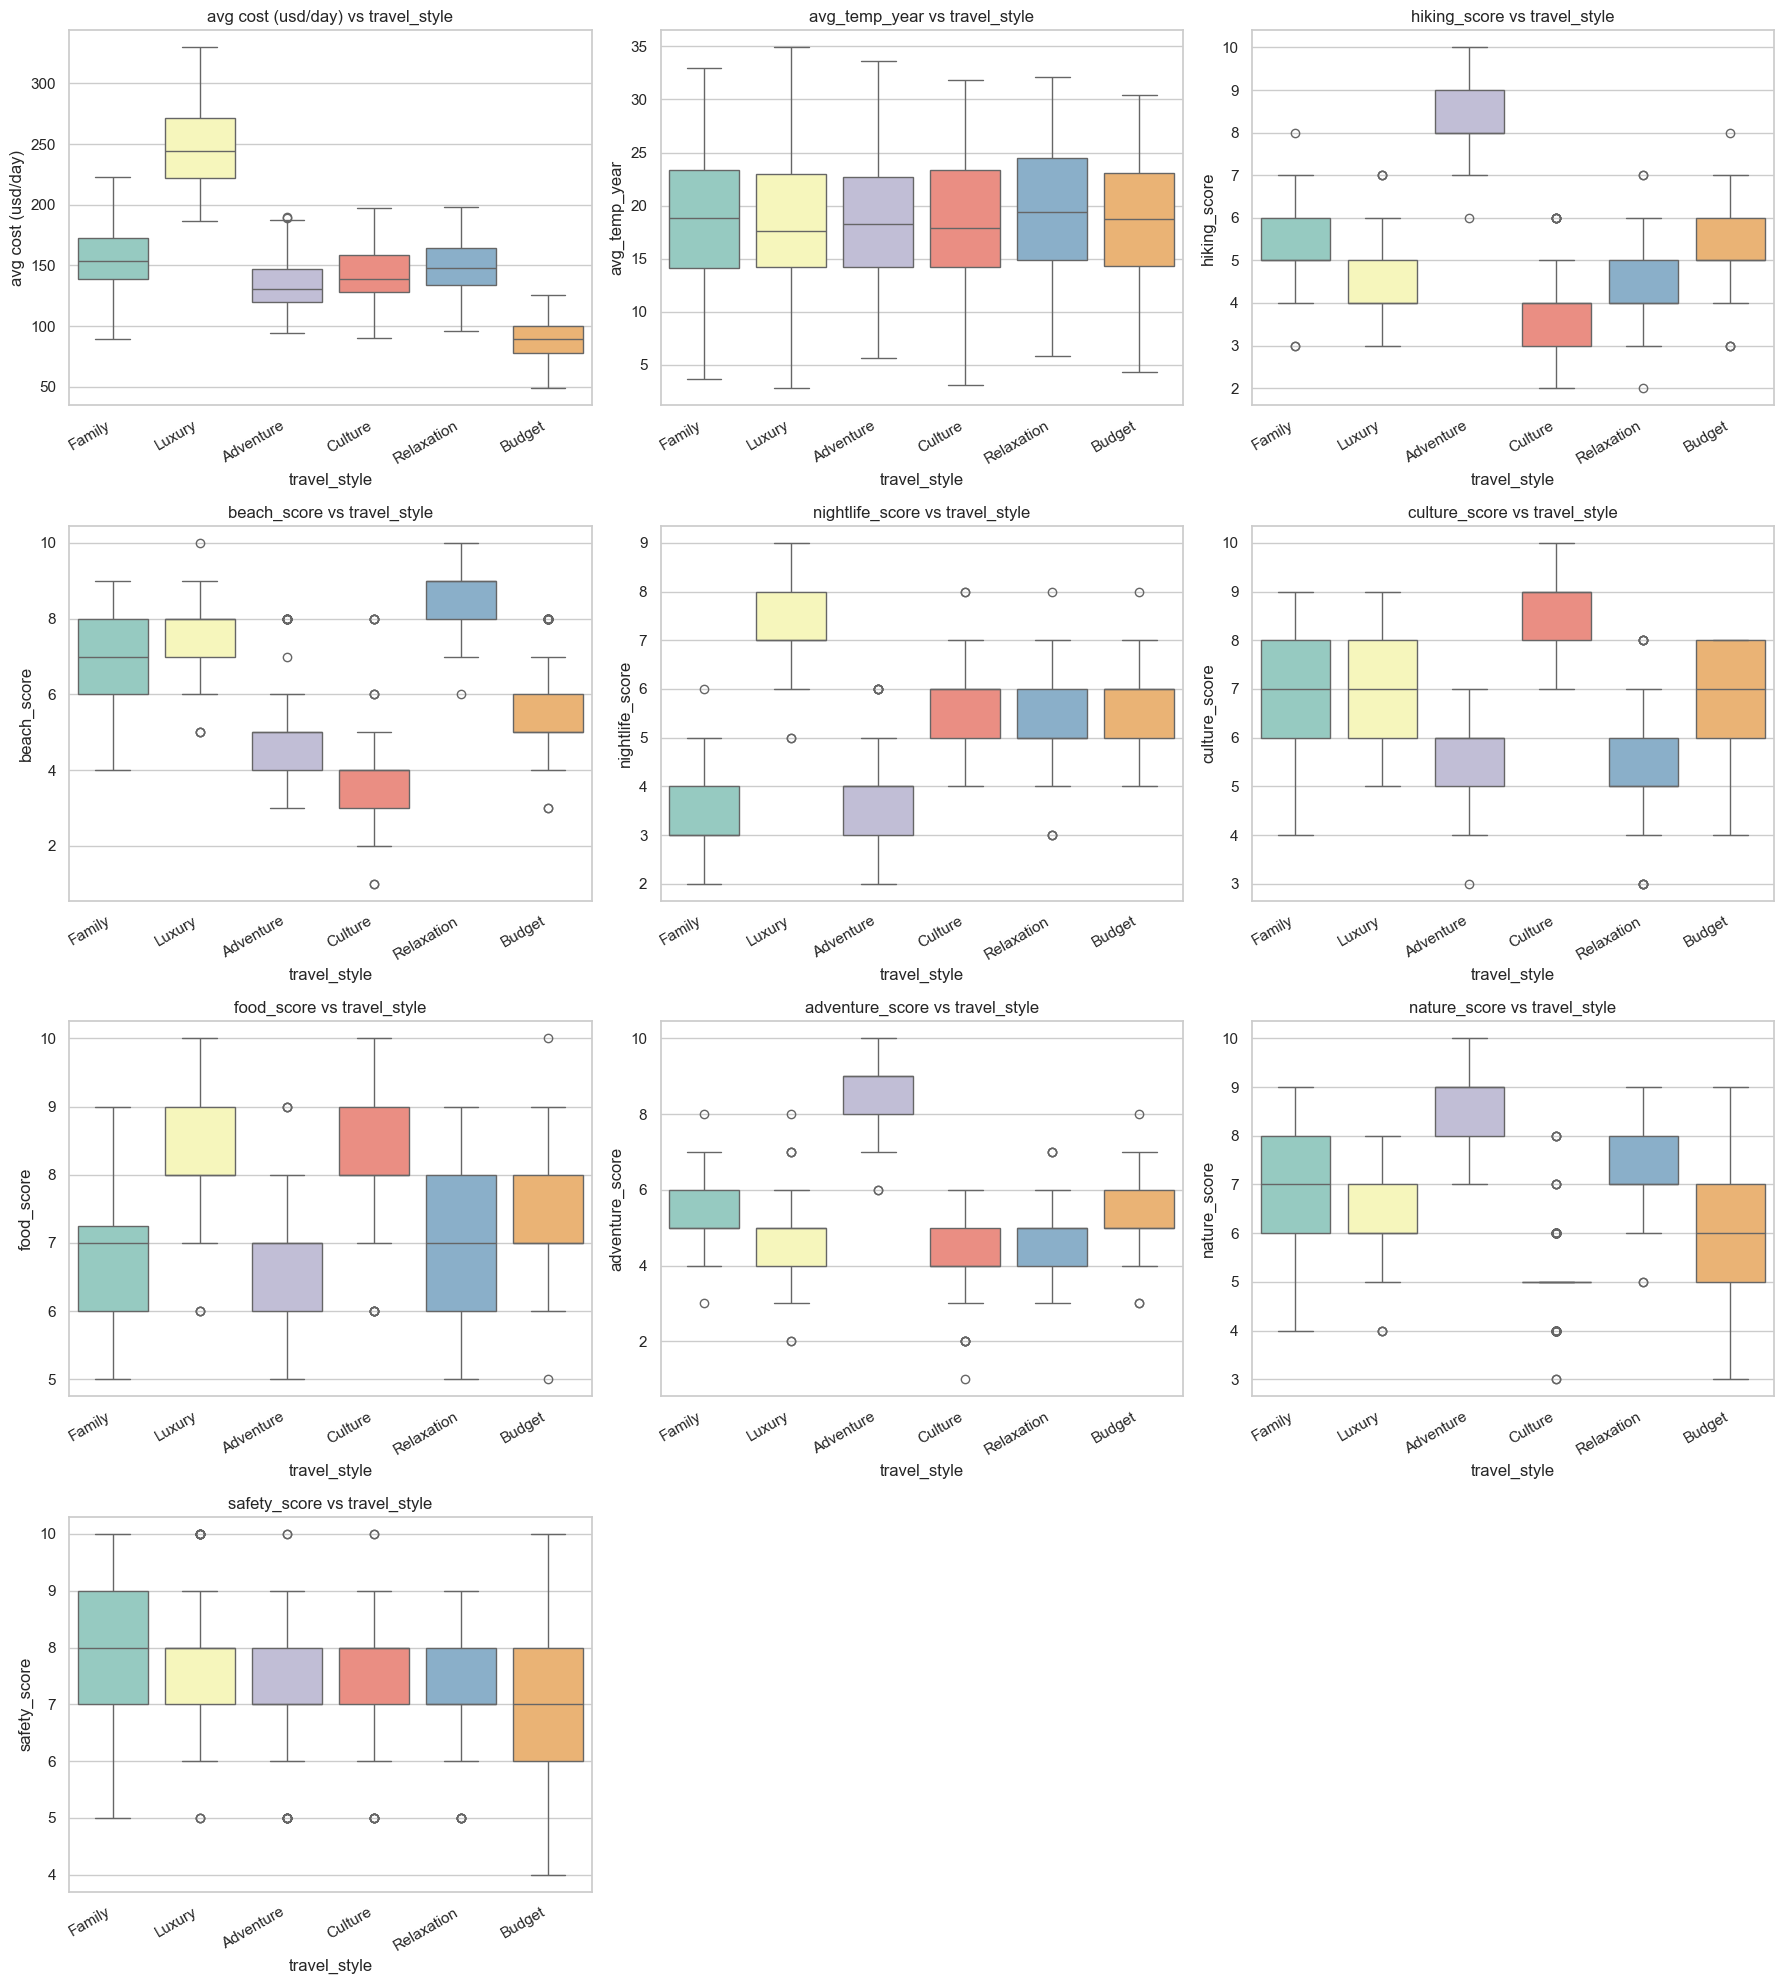

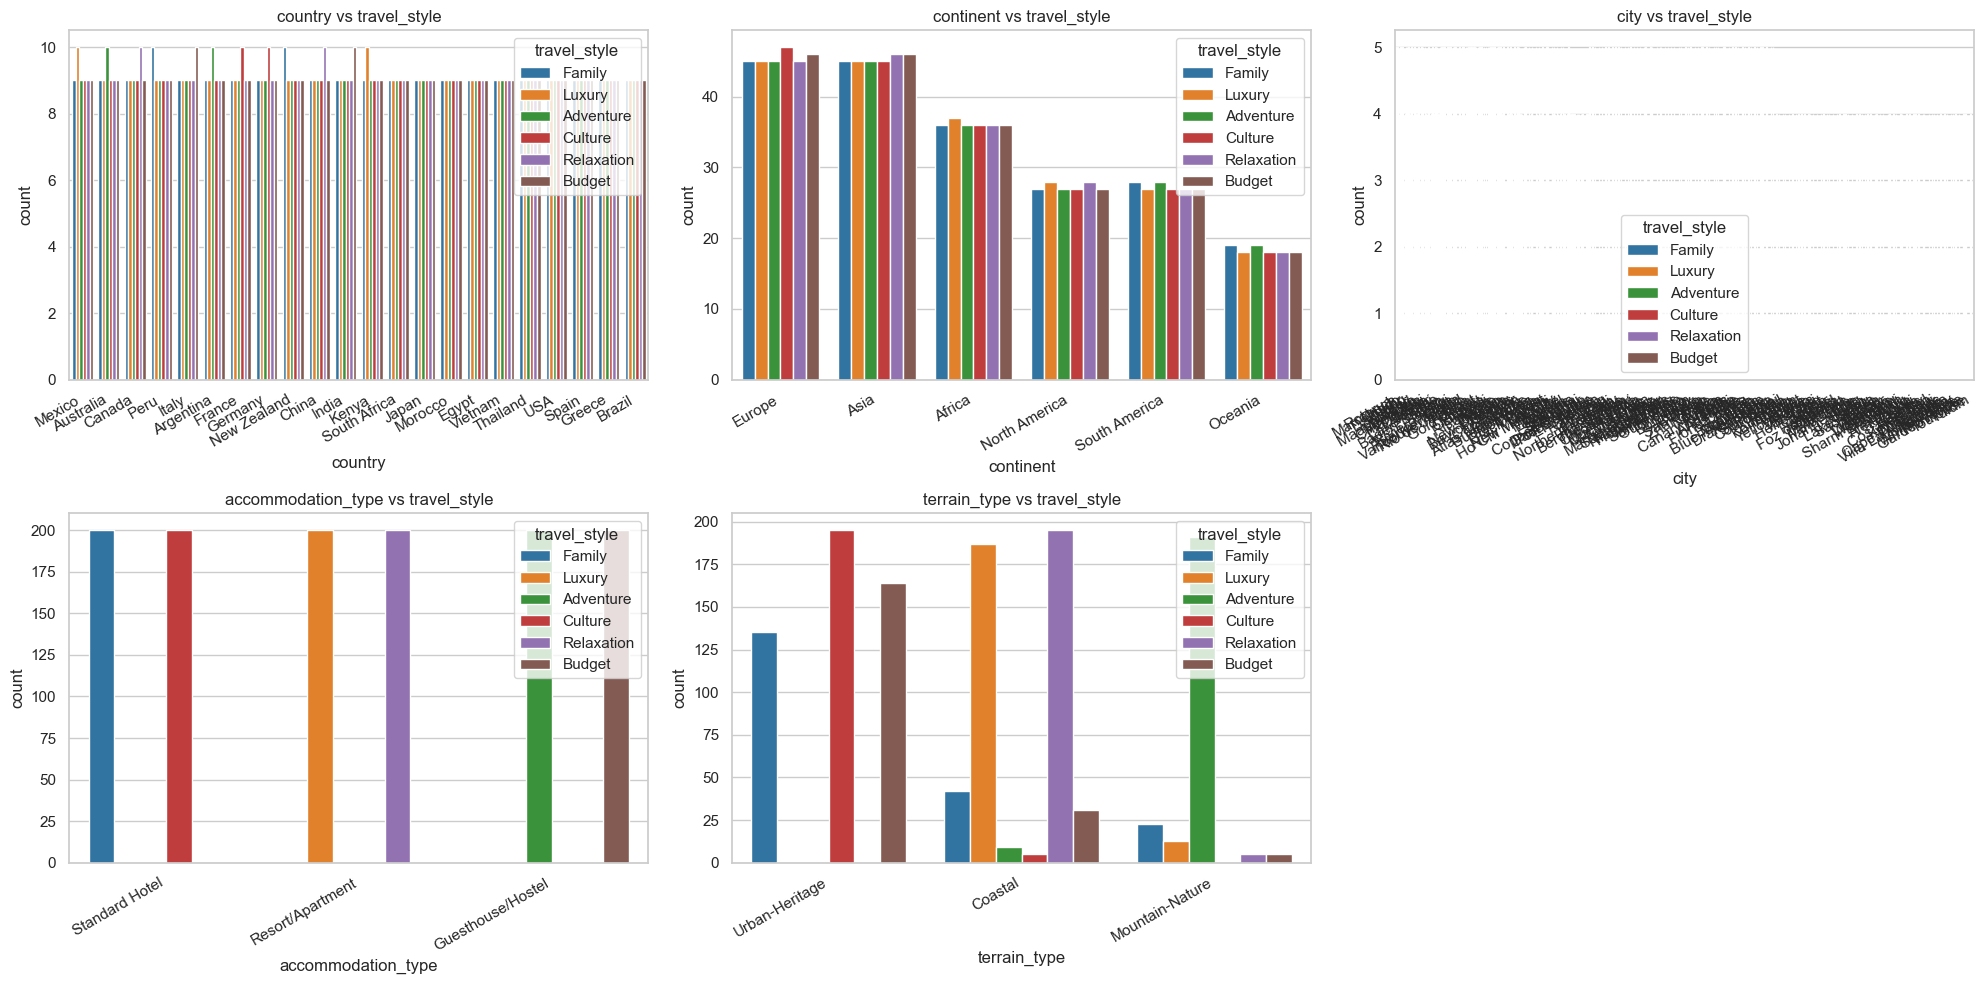

In [157]:
# -----------------------------
# FEATURES VS TARGET
# Numeric features: boxplots by target
# Categorical features: countplots with target hue
# -----------------------------
if TARGET_COL is not None:
    if feature_numeric_cols:
        n_cols = 3
        n_rows = int(np.ceil(len(feature_numeric_cols) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
        axes = np.array(axes).reshape(-1)

        for ax, col in zip(axes, feature_numeric_cols):
            sns.boxplot(
                data=df,
                x=TARGET_COL,
                y=col,
                hue=TARGET_COL,
                palette="Set3",
                legend=False,
                ax=ax,
            )
            ax.set_title(f"{col} vs {TARGET_COL}")
            ax.tick_params(axis="x", rotation=30)
            for label in ax.get_xticklabels():
                label.set_ha("right")

        for ax in axes[len(feature_numeric_cols):]:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

    if feature_categorical_cols:
        n_cols = 3
        n_rows = int(np.ceil(len(feature_categorical_cols) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
        axes = np.array(axes).reshape(-1)

        for ax, col in zip(axes, feature_categorical_cols):
            plot_df = df.copy()
            plot_df[col] = plot_df[col].fillna("Missing")
            order = plot_df[col].value_counts().index

            sns.countplot(
                data=plot_df,
                x=col,
                hue=TARGET_COL,
                order=order,
                palette="tab10",
                ax=ax,
            )
            ax.set_title(f"{col} vs {TARGET_COL}")
            ax.tick_params(axis="x", rotation=30)
            for label in ax.get_xticklabels():
                label.set_ha("right")

        for ax in axes[len(feature_categorical_cols):]:
            ax.axis("off")

        plt.tight_layout()
        plt.show()
else:
    print("Skipping feature-vs-target plots because TARGET_COL is not set.")

# target-varient features:
# avg cost (usd/day), hiking_score, beach_score, nightlife_score, culture_score, food_score, adventure_score, nature_score, safety_score

# temp: not changing.

## Correlation Review
This subsection identifies highly correlated numeric features and prepares the feature-selection notes below.


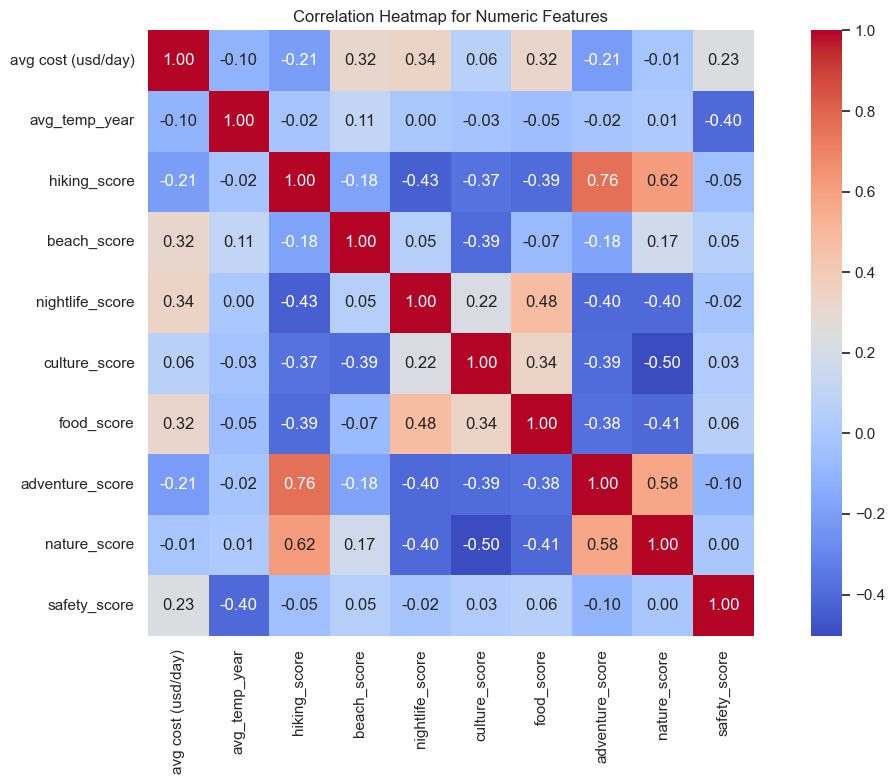

,feature_1,feature_2,correlation


In [158]:
# -----------------------------
# CORRELATION ANALYSIS
# -----------------------------
if len(feature_numeric_cols) >= 2:
    corr_matrix = df[feature_numeric_cols].corr()

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
    plt.title("Correlation Heatmap for Numeric Features")
    plt.tight_layout()
    plt.show()

    high_corr_pairs = []
    for i, col_1 in enumerate(corr_matrix.columns):
        for j, col_2 in enumerate(corr_matrix.columns):
            if j > i and abs(corr_matrix.loc[col_1, col_2]) >= 0.8:
                high_corr_pairs.append({
                    "feature_1": col_1,
                    "feature_2": col_2,
                    "correlation": round(corr_matrix.loc[col_1, col_2], 3),
                })

    if high_corr_pairs:
        high_corr_pairs_df = pd.DataFrame(high_corr_pairs).sort_values(
            "correlation", key=lambda s: s.abs(), ascending=False
        )
    else:
        high_corr_pairs_df = pd.DataFrame(
            columns=["feature_1", "feature_2", "correlation"]
        )

    display(high_corr_pairs_df)
else:
    print("Not enough numeric features to compute pairwise correlations.")


## Feature Selection Notes

In [159]:
# -----------------------------
# SIMPLE FEATURE SELECTION
# Low-variance columns can contribute little information to a model.
# -----------------------------
variance_summary = pd.DataFrame({
    "feature": feature_numeric_cols,
    "variance": df[feature_numeric_cols].var(numeric_only=True).values,
}).sort_values("variance")

# A very small threshold is used here because most scores are on a 1-10 scale.
low_variance_features = variance_summary[variance_summary["variance"] <= 0.01]

display(variance_summary.round(4))
print("Potential low-variance features (variance <= 0.01):")

if not low_variance_features.empty:
    display(low_variance_features.round(4))
else:
    display(pd.DataFrame({
        "message": ["No low-variance numeric features detected with the current threshold."]
    }))


,feature,variance
6,food_score,1.1972
9,safety_score,1.1980
8,nature_score,2.0054
4,nightlife_score,2.2706
5,culture_score,2.2964
2,hiking_score,2.9287
7,adventure_score,2.9642
3,beach_score,3.7924
1,avg_temp_year,36.1267
0,avg cost (usd/day),2920.3512


Potential low-variance features (variance <= 0.01):


,message
0,No low-variance numeric features detected with...


# 4- Train/Test Split and Preprocessing Pipeline
The data is prepared with a leakage-safe workflow. A `70/30` stratified split is used, high-cardinality location identifiers are removed, and all preprocessing steps are fit on the training set only.


In [160]:
# -----------------------------
# SPLIT SETUP
# -----------------------------
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Drop broad geographic columns before training.
drop_columns = ["country", "city", "continent"]

model_df = df.drop(columns=drop_columns).copy()
X = model_df.drop(columns=[TARGET_COL])
y = model_df[TARGET_COL]

model_numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
model_categorical_cols = X.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()

print(f"Dropped before train/test split: {drop_columns}")
print(f"Model feature shape before split: {X.shape}")
print(f"Numeric columns used in the pipeline: {model_numeric_cols}")
print(f"Categorical columns used in the pipeline: {model_categorical_cols}")


Dropped before train/test split: ['country', 'city', 'continent']
Model feature shape before split: (1200, 12)
Numeric columns used in the pipeline: ['avg cost (usd/day)', 'avg_temp_year', 'hiking_score', 'beach_score', 'nightlife_score', 'culture_score', 'food_score', 'adventure_score', 'nature_score', 'safety_score']
Categorical columns used in the pipeline: ['accommodation_type', 'terrain_type']


In [161]:
# -----------------------------
# 70/30 TRAIN-TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

split_summary = pd.DataFrame({
    "train_count": y_train.value_counts().sort_index(),
    "test_count": y_test.value_counts().sort_index(),
    "train_percentage": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    "test_percentage": (y_test.value_counts(normalize=True).sort_index() * 100).round(2),
})

display(split_summary)


X_train shape: (840, 12)
X_test shape: (360, 12)
y_train shape: (840,)
y_test shape: (360,)


,train_count,test_count,train_percentage,test_percentage
travel_style,,,,
Adventure,140,60,16.67,16.67
Budget,140,60,16.67,16.67
Culture,140,60,16.67,16.67
Family,140,60,16.67,16.67
Luxury,140,60,16.67,16.67
Relaxation,140,60,16.67,16.67


In [162]:
# -----------------------------
# PREPROCESSING PIPELINE
# Numeric: median imputation + standard scaling
# Categorical: most-frequent imputation + one-hot encoding
# All steps are fit on X_train only to avoid data leakage.
# -----------------------------
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, model_numeric_cols),
    ("cat", categorical_pipeline, model_categorical_cols),
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing pipeline fitted on training data only.")
print(f"Processed X_train shape: {X_train_processed.shape}")
print(f"Processed X_test shape: {X_test_processed.shape}")


Preprocessing pipeline fitted on training data only.
Processed X_train shape: (840, 16)
Processed X_test shape: (360, 16)


In [163]:
# -----------------------------
# TRANSFORMED FEATURE CHECK
# -----------------------------
transformed_feature_names = preprocessor.get_feature_names_out()

display(pd.DataFrame({
    "transformed_feature_name": transformed_feature_names
}).head(20))

print(f"Total transformed features after preprocessing: {len(transformed_feature_names)}")


,transformed_feature_name
0,num__avg cost (usd/day)
1,num__avg_temp_year
2,num__hiking_score
3,num__beach_score
4,num__nightlife_score
5,num__culture_score
6,num__food_score
7,num__adventure_score
8,num__nature_score
9,num__safety_score


Total transformed features after preprocessing: 16


## Representation: PCA
PCA is used here only as a representation and visualization tool after preprocessing. It is not the default feature space used for model training.


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.3140,0.3140
1,2,0.1890,0.5030
2,3,0.1321,0.6350
3,4,0.0916,0.7266
4,5,0.0679,0.7945
5,6,0.0486,0.8432
6,7,0.0442,0.8874
7,8,0.0334,0.9208
8,9,0.0293,0.9501
9,10,0.0205,0.9706


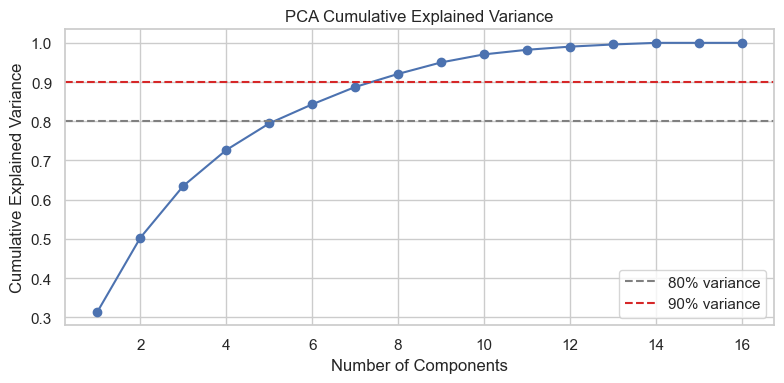

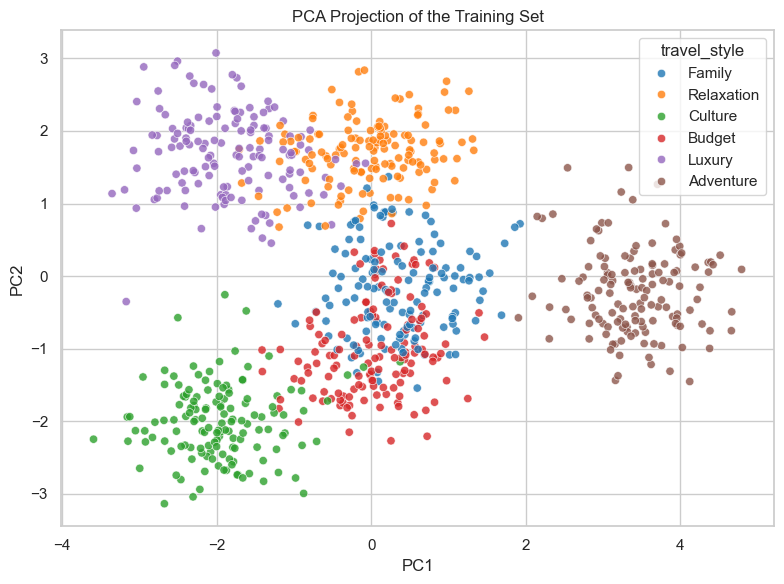

In [164]:
# -----------------------------
# PCA REPRESENTATION
# -----------------------------
from sklearn.decomposition import PCA

pca_full = PCA(random_state=42)
X_train_pca_full = pca_full.fit_transform(X_train_processed)

explained_variance_df = pd.DataFrame({
    "component": np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca_full.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca_full.explained_variance_ratio_),
})

display(explained_variance_df.head(10).round(4))

plt.figure(figsize=(8, 4))
plt.plot(
    explained_variance_df["component"],
    explained_variance_df["cumulative_explained_variance"],
    marker="o",
)
plt.axhline(0.80, linestyle="--", color="gray", label="80% variance")
plt.axhline(0.90, linestyle="--", color="tab:red", label="90% variance")
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

pca_2d = PCA(n_components=2, random_state=42)
X_train_pca_2d = pca_2d.fit_transform(X_train_processed)

pca_plot_df = pd.DataFrame({
    "PC1": X_train_pca_2d[:, 0],
    "PC2": X_train_pca_2d[:, 1],
    "travel_style": y_train.reset_index(drop=True),
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="travel_style",
    palette="tab10",
    alpha=0.8,
)
plt.title("PCA Projection of the Training Set")
plt.tight_layout()
plt.show()


## PCA Interpretation
This subsection turns the PCA output into a short interpretation. It helps explain whether some travel styles cluster cleanly or overlap in the reduced 2D view.


In [165]:
# -----------------------------
# PCA INTERPRETATION
# -----------------------------
pca_centroids = (
    pca_plot_df.groupby("travel_style")[["PC1", "PC2"]]
    .mean()
    .sort_index()
)

centroid_pairs = []
labels = pca_centroids.index.tolist()
for i, label_i in enumerate(labels):
    for j, label_j in enumerate(labels):
        if j > i:
            point_i = pca_centroids.loc[label_i].values
            point_j = pca_centroids.loc[label_j].values
            distance = np.linalg.norm(point_i - point_j)
            centroid_pairs.append({
                "label_1": label_i,
                "label_2": label_j,
                "centroid_distance": distance,
            })

centroid_distance_df = pd.DataFrame(centroid_pairs).sort_values("centroid_distance")
display(centroid_distance_df.round(3).head(5))

closest_pair = centroid_distance_df.iloc[0]
variance_2d = pca_2d.explained_variance_ratio_.sum()

print(
    f"The first two principal components explain about {variance_2d:.2%} of the variance. "
    f"The closest PCA centroids are {closest_pair['label_1']} and {closest_pair['label_2']}, "
    f"which suggests that these two travel styles share similar feature patterns in the reduced representation."
)


,label_1,label_2,centroid_distance
6,Budget,Family,0.898
14,Luxury,Relaxation,1.815
13,Family,Relaxation,1.914
5,Budget,Culture,2.235
8,Budget,Relaxation,2.716


The first two principal components explain about 50.30% of the variance. The closest PCA centroids are Budget and Family, which suggests that these two travel styles share similar feature patterns in the reduced representation.


# 5- Model Training and Evaluation
This section follows a simpler modeling workflow:
1. train three baseline models with k-fold cross-validation
2. compare them and identify the best baseline
3. tune all three models
4. compare tuned vs baseline results and select the best final model
5. test thresholding only on the best final model
6. save the best full pipeline for backend reuse

Reported metrics in all main comparison tables:
- accuracy
- macro F1
- macro precision
- macro recall

For cross-validation, each metric is shown with mean and standard deviation.


## Baseline Evaluation Setup
The following cells define the reusable helpers, fixed seeds, experiment tracking, and the three baseline models.


In [166]:
# -----------------------------
# MODELING IMPORTS, REPRODUCIBILITY, AND TRACKING HELPERS
# -----------------------------
import json
from datetime import datetime, timezone
import joblib
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
class_names = sorted(y_train.unique())

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)
RESULTS_CSV_PATH = ARTIFACTS_DIR / "results.csv"
MODEL_OUTPUT_PATH = ARTIFACTS_DIR / "best_model.joblib"

def make_model_pipeline(model):
    return Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", model),
    ])

def classification_report_df(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return pd.DataFrame(report).T.round(3)

def metric_row(model_name, y_true, y_pred):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

def run_cv(model_name, estimator, X, y, cv):
    fold_rows = []
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        X_tr = X.iloc[train_idx]
        X_v = X.iloc[val_idx]
        y_tr = y.iloc[train_idx]
        y_v = y.iloc[val_idx]

        fitted = clone(estimator)
        fitted.fit(X_tr, y_tr)
        y_v_pred = fitted.predict(X_v)

        row = metric_row(model_name, y_v, y_v_pred)
        row["fold"] = fold_idx
        fold_rows.append(row)

    return pd.DataFrame(fold_rows)

def summarize_cv(cv_df):
    metrics = ["accuracy", "macro_f1", "macro_precision", "macro_recall"]
    summary = {"model": cv_df["model"].iloc[0]}
    for metric in metrics:
        summary[f"{metric}_mean"] = cv_df[metric].mean()
        summary[f"{metric}_std"] = cv_df[metric].std(ddof=1)
    return summary

def evaluate_holdout(model_name, fitted_model, X_train, y_train, X_test, y_test):
    y_train_pred = fitted_model.predict(X_train)
    y_test_pred = fitted_model.predict(X_test)
    test_row = metric_row(model_name, y_test, y_test_pred)
    train_row = metric_row(model_name, y_train, y_train_pred)
    return {
        **{f"train_{k}": v for k, v in train_row.items() if k != "model"},
        **{f"test_{k}": v for k, v in test_row.items() if k != "model"},
    }, y_train_pred, y_test_pred

def append_experiment_row(model_name, params_dict, metrics_dict, notes):
    row = {
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "model": model_name,
        "params": json.dumps(params_dict, sort_keys=True),
        "notes": notes,
    }
    row.update(metrics_dict)
    experiment_df = pd.DataFrame([row])
    if RESULTS_CSV_PATH.exists():
        experiment_df.to_csv(RESULTS_CSV_PATH, mode="a", header=False, index=False)
    else:
        experiment_df.to_csv(RESULTS_CSV_PATH, index=False)

def predict_with_global_threshold(probabilities, class_names, threshold):
    predictions = []
    for row in probabilities:
        eligible_indices = [idx for idx, prob in enumerate(row) if prob >= threshold]
        if eligible_indices:
            best_index = eligible_indices[np.argmax(row[eligible_indices])]
        else:
            best_index = int(np.argmax(row))
        predictions.append(class_names[best_index])
    return np.array(predictions)


In [167]:
# -----------------------------
# DEFINE BASELINE MODELS
# The dataset is balanced, so no class weighting is applied.
# -----------------------------
baseline_models = {
    "LR": make_model_pipeline(
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    ),
    "RF": make_model_pipeline(
        RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    ),
    "GBM": make_model_pipeline(
        HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=250,
            max_depth=6,
            min_samples_leaf=10,
            random_state=RANDOM_STATE,
        )
    ),
}

display(pd.DataFrame({
    "model": list(baseline_models.keys()),
    "baseline_reason": [
        "Linear classifier baseline",
        "Bagged tree baseline",
        "Boosted tree baseline",
    ],
}))


,model,baseline_reason
0,LR,Linear classifier baseline
1,RF,Bagged tree baseline
2,GBM,Boosted tree baseline


In [168]:
# -----------------------------
# BASELINE CROSS-VALIDATION RESULTS
# -----------------------------
baseline_cv_folds = {}
baseline_cv_summary_rows = []

for model_name, estimator in baseline_models.items():
    cv_df = run_cv(model_name, estimator, X_train, y_train, cv)
    baseline_cv_folds[model_name] = cv_df
    baseline_cv_summary_rows.append(summarize_cv(cv_df))

baseline_cv_summary = (
    pd.DataFrame(baseline_cv_summary_rows)
    .set_index("model")
    .sort_values("macro_f1_mean", ascending=False)
    .round(3)
)

display(baseline_cv_summary)


,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,macro_precision_mean,macro_precision_std,macro_recall_mean,macro_recall_std
model,,,,,,,,
LR,0.994,0.004,0.994,0.004,0.994,0.004,0.994,0.004
RF,0.994,0.006,0.994,0.006,0.994,0.006,0.994,0.006
GBM,0.992,0.007,0.992,0.007,0.992,0.007,0.992,0.007


## Baseline Comparison Summary
Use the next two outputs together:
- the CV summary tells us which model is strongest and most stable across folds
- the hold-out evaluation tells us how each fitted baseline behaves on unseen test data


In [169]:
# -----------------------------
# BASELINE HOLD-OUT RESULTS + PER-CLASS REPORTS
# -----------------------------
fitted_baselines = {}
baseline_test_summary_rows = []
baseline_per_class_reports = {}
baseline_test_probabilities = {}

for model_name, estimator in baseline_models.items():
    fitted = clone(estimator)
    fitted.fit(X_train, y_train)
    fitted_baselines[model_name] = fitted

    holdout_metrics, y_train_pred, y_test_pred = evaluate_holdout(
        model_name,
        fitted,
        X_train,
        y_train,
        X_test,
        y_test,
    )
    baseline_test_summary_rows.append({"model": model_name, **holdout_metrics})
    baseline_per_class_reports[model_name] = classification_report_df(y_test, y_test_pred)
    baseline_test_probabilities[model_name] = fitted.predict_proba(X_test)

    append_experiment_row(
        model_name=model_name,
        params_dict=fitted.named_steps["model"].get_params(),
        metrics_dict={**baseline_cv_summary.loc[model_name].to_dict(), **holdout_metrics},
        notes="baseline",
    )

baseline_test_summary = (
    pd.DataFrame(baseline_test_summary_rows)
    .set_index("model")
    .sort_values("test_macro_f1", ascending=False)
    .round(3)
)

display(baseline_test_summary)


,train_accuracy,train_macro_f1,train_macro_precision,train_macro_recall,test_accuracy,test_macro_f1,test_macro_precision,test_macro_recall
model,,,,,,,,
LR,0.999,0.999,0.999,0.999,0.989,0.989,0.989,0.989
GBM,1.000,1.000,1.000,1.000,0.989,0.989,0.989,0.989
RF,1.000,1.000,1.000,1.000,0.986,0.986,0.987,0.986


In [170]:
# -----------------------------
# BASELINE INTERPRETATION AND PER-CLASS REPORTS
# -----------------------------
best_baseline_name = baseline_cv_summary.index[0]
print(
    f"Best baseline from CV: {best_baseline_name} "
    f"with macro F1 = {baseline_cv_summary.loc[best_baseline_name, 'macro_f1_mean']:.3f} "
    f"+/- {baseline_cv_summary.loc[best_baseline_name, 'macro_f1_std']:.3f}."
)
print(
    "The per-class reports below should confirm whether the strongest overall baseline is also balanced across all travel styles."
)

for model_name, report_df in baseline_per_class_reports.items():
    print(f"Per-class report for {model_name}")
    display(report_df)


Best baseline from CV: LR with macro F1 = 0.994 +/- 0.004.
The per-class reports below should confirm whether the strongest overall baseline is also balanced across all travel styles.
Per-class report for LR


,precision,recall,f1-score,support
Adventure,1.000,1.000,1.000,60.000
Budget,1.000,1.000,1.000,60.000
Culture,0.984,1.000,0.992,60.000
Family,1.000,0.983,0.992,60.000
Luxury,0.983,0.967,0.975,60.000
Relaxation,0.967,0.983,0.975,60.000
accuracy,0.989,0.989,0.989,0.989
macro avg,0.989,0.989,0.989,360.000
weighted avg,0.989,0.989,0.989,360.000


Per-class report for RF


,precision,recall,f1-score,support
Adventure,0.984,1.000,0.992,60.000
Budget,1.000,0.983,0.992,60.000
Culture,0.968,1.000,0.984,60.000
Family,1.000,0.967,0.983,60.000
Luxury,1.000,0.967,0.983,60.000
Relaxation,0.968,1.000,0.984,60.000
accuracy,0.986,0.986,0.986,0.986
macro avg,0.987,0.986,0.986,360.000
weighted avg,0.987,0.986,0.986,360.000


Per-class report for GBM


,precision,recall,f1-score,support
Adventure,1.000,1.000,1.000,60.000
Budget,1.000,1.000,1.000,60.000
Culture,0.968,1.000,0.984,60.000
Family,1.000,0.967,0.983,60.000
Luxury,1.000,0.967,0.983,60.000
Relaxation,0.968,1.000,0.984,60.000
accuracy,0.989,0.989,0.989,0.989
macro avg,0.989,0.989,0.989,360.000
weighted avg,0.989,0.989,0.989,360.000


# 6- Hyperparameter Tuning
All three models are tuned, not just one. Then the notebook compares the best tuned version of each model and selects the final winner.


## Tuning Strategy
The search spaces focus on the most meaningful parameters for each model family:
- `LR`: regularization strength and solver
- `RF`: number of trees, depth, split rules, and feature sampling
- `GBM`: learning rate, boosting rounds, depth, leaf size, and regularization


In [171]:
# -----------------------------
# DEFINE SEARCH SPACES FOR ALL THREE MODELS
# -----------------------------
tuning_specs = {
    "LR": {
        "estimator": make_model_pipeline(
            LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
        ),
        "search_space": {
            "model__C": np.logspace(-3, 2, 12),
            "model__solver": ["lbfgs", "newton-cg", "sag", "saga"],
        },
        "n_iter": 12,
    },
    "RF": {
        "estimator": make_model_pipeline(
            RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
        ),
        "search_space": {
            "model__n_estimators": [200, 300, 500, 700],
            "model__max_depth": [None, 6, 10, 14, 20],
            "model__min_samples_split": [2, 4, 6, 10],
            "model__min_samples_leaf": [1, 2, 4, 6],
            "model__max_features": ["sqrt", "log2", 0.6, 0.8],
        },
        "n_iter": 20,
    },
    "GBM": {
        "estimator": make_model_pipeline(
            HistGradientBoostingClassifier(random_state=RANDOM_STATE)
        ),
        "search_space": {
            "model__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
            "model__max_iter": [150, 250, 350, 500],
            "model__max_depth": [None, 4, 6, 8, 10],
            "model__min_samples_leaf": [5, 10, 15, 20],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__l2_regularization": [0.0, 0.01, 0.1, 1.0],
        },
        "n_iter": 20,
    },
}

tuning_space_preview = []
for model_name, spec in tuning_specs.items():
    for param_name, values in spec["search_space"].items():
        tuning_space_preview.append({
            "model": model_name,
            "parameter": param_name,
            "values": str(values),
        })

display(pd.DataFrame(tuning_space_preview))


,model,parameter,values
0,LR,model__C,[1.00000000e-03 2.84803587e-03 8.11130831e-03 ...
1,LR,model__solver,"['lbfgs', 'newton-cg', 'sag', 'saga']"
2,RF,model__n_estimators,"[200, 300, 500, 700]"
3,RF,model__max_depth,"[None, 6, 10, 14, 20]"
4,RF,model__min_samples_split,"[2, 4, 6, 10]"
5,RF,model__min_samples_leaf,"[1, 2, 4, 6]"
6,RF,model__max_features,"['sqrt', 'log2', 0.6, 0.8]"
7,GBM,model__learning_rate,"[0.01, 0.03, 0.05, 0.08, 0.1]"
8,GBM,model__max_iter,"[150, 250, 350, 500]"
9,GBM,model__max_depth,"[None, 4, 6, 8, 10]"


In [172]:
# -----------------------------
# TUNE ALL THREE MODELS
# -----------------------------
tuned_models = {}
tuned_test_summary_rows = []
tuned_per_class_reports = {}
tuning_result_rows = []

for model_name, spec in tuning_specs.items():
    search = RandomizedSearchCV(
        estimator=spec["estimator"],
        param_distributions=spec["search_space"],
        n_iter=spec["n_iter"],
        scoring="f1_macro",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=1,
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    tuned_models[model_name] = best_model

    holdout_metrics, _, y_test_pred = evaluate_holdout(
        f"Tuned {model_name}",
        best_model,
        X_train,
        y_train,
        X_test,
        y_test,
    )
    tuned_test_summary_rows.append({
        "model": model_name,
        "best_cv_macro_f1": search.best_score_,
        **holdout_metrics,
    })
    tuned_per_class_reports[model_name] = classification_report_df(y_test, y_test_pred)

    tuning_result_rows.append({
        "model": model_name,
        "best_cv_macro_f1": search.best_score_,
        "best_params": json.dumps(search.best_params_, sort_keys=True),
    })

    append_experiment_row(
        model_name=f"Tuned {model_name}",
        params_dict=best_model.named_steps["model"].get_params(),
        metrics_dict={"best_cv_macro_f1": search.best_score_, **holdout_metrics},
        notes="tuned",
    )

tuning_results_df = pd.DataFrame(tuning_result_rows).set_index("model")
tuned_test_summary = (
    pd.DataFrame(tuned_test_summary_rows)
    .set_index("model")
    .sort_values("test_macro_f1", ascending=False)
    .round(3)
)

display(tuning_results_df)
display(tuned_test_summary)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


,best_cv_macro_f1,best_params
model,,
LR,0.995237,"{""model__C"": 0.02310129700083159, ""model__solv..."
RF,0.994046,"{""model__max_depth"": 14, ""model__max_features""..."
GBM,0.994046,"{""model__l2_regularization"": 1.0, ""model__lear..."


,best_cv_macro_f1,train_accuracy,train_macro_f1,train_macro_precision,train_macro_recall,test_accuracy,test_macro_f1,test_macro_precision,test_macro_recall
model,,,,,,,,,
LR,0.995,0.996,0.996,0.996,0.996,0.992,0.992,0.992,0.992
GBM,0.994,1.000,1.000,1.000,1.000,0.989,0.989,0.989,0.989
RF,0.994,1.000,1.000,1.000,1.000,0.986,0.986,0.987,0.986


## Tuned Model Result Summary
The next outputs show:
- the best CV result and parameter set for each tuned model
- the tuned hold-out comparison table
- the per-class reports for the tuned versions

The final winner should come from this tuned comparison, not from the baseline section.


In [173]:
# -----------------------------
# TUNED VS BASELINE COMPARISON + PER-CLASS REPORTS
# -----------------------------
comparison_rows = []
for model_name in baseline_models.keys():
    comparison_rows.append({
        "model": model_name,
        "baseline_cv_macro_f1": baseline_cv_summary.loc[model_name, "macro_f1_mean"],
        "tuned_cv_macro_f1": tuning_results_df.loc[model_name, "best_cv_macro_f1"],
        "baseline_test_macro_f1": baseline_test_summary.loc[model_name, "test_macro_f1"],
        "tuned_test_macro_f1": tuned_test_summary.loc[model_name, "test_macro_f1"],
    })

tuned_vs_baseline_df = pd.DataFrame(comparison_rows).set_index("model").round(3)
display(tuned_vs_baseline_df)

final_best_model_name = tuned_test_summary.index[0]
final_best_pipeline = tuned_models[final_best_model_name]

print(f"Best final model after tuning: {final_best_model_name}")
print(
    f"Hold-out macro F1 = {tuned_test_summary.loc[final_best_model_name, 'test_macro_f1']:.3f}, "
    f"accuracy = {tuned_test_summary.loc[final_best_model_name, 'test_accuracy']:.3f}."
)

for model_name, report_df in tuned_per_class_reports.items():
    print(f"Per-class report for tuned {model_name}")
    display(report_df)


,baseline_cv_macro_f1,tuned_cv_macro_f1,baseline_test_macro_f1,tuned_test_macro_f1
model,,,,
LR,0.994,0.995,0.989,0.992
RF,0.994,0.994,0.986,0.986
GBM,0.992,0.994,0.989,0.989


Best final model after tuning: LR
Hold-out macro F1 = 0.992, accuracy = 0.992.
Per-class report for tuned LR


,precision,recall,f1-score,support
Adventure,1.000,1.000,1.000,60.000
Budget,1.000,1.000,1.000,60.000
Culture,0.984,1.000,0.992,60.000
Family,1.000,0.983,0.992,60.000
Luxury,0.983,0.983,0.983,60.000
Relaxation,0.983,0.983,0.983,60.000
accuracy,0.992,0.992,0.992,0.992
macro avg,0.992,0.992,0.992,360.000
weighted avg,0.992,0.992,0.992,360.000


Per-class report for tuned RF


,precision,recall,f1-score,support
Adventure,0.984,1.000,0.992,60.000
Budget,1.000,0.983,0.992,60.000
Culture,0.968,1.000,0.984,60.000
Family,1.000,0.967,0.983,60.000
Luxury,1.000,0.967,0.983,60.000
Relaxation,0.968,1.000,0.984,60.000
accuracy,0.986,0.986,0.986,0.986
macro avg,0.987,0.986,0.986,360.000
weighted avg,0.987,0.986,0.986,360.000


Per-class report for tuned GBM


,precision,recall,f1-score,support
Adventure,1.000,1.000,1.000,60.000
Budget,1.000,1.000,1.000,60.000
Culture,0.968,1.000,0.984,60.000
Family,1.000,0.967,0.983,60.000
Luxury,1.000,0.967,0.983,60.000
Relaxation,0.968,1.000,0.984,60.000
accuracy,0.989,0.989,0.989,0.989
macro avg,0.989,0.989,0.989,360.000
weighted avg,0.989,0.989,0.989,360.000


# 7- Threshold Analysis on the Best Final Model
Thresholding is tested only on the best final tuned model. A single global probability threshold is searched and the notebook reports macro F1, macro precision, and macro recall for each threshold.

In the current results, the tested thresholds produce the same metrics as the default prediction rule, so the default strategy is kept.


In [174]:
# -----------------------------
# THRESHOLD SEARCH ON THE BEST FINAL MODEL
# -----------------------------
best_model_pipeline = tuned_models[final_best_model_name]
best_model_test_proba = best_model_pipeline.predict_proba(X_test)
best_model_default_pred = best_model_pipeline.predict(X_test)

default_threshold_metrics = {
    "threshold": "default",
    "macro_f1": f1_score(y_test, best_model_default_pred, average="macro", zero_division=0),
    "macro_precision": precision_score(y_test, best_model_default_pred, average="macro", zero_division=0),
    "macro_recall": recall_score(y_test, best_model_default_pred, average="macro", zero_division=0),
}

threshold_grid = np.linspace(0.10, 0.90, 17)
threshold_rows = []

for threshold in threshold_grid:
    threshold_pred = predict_with_global_threshold(best_model_test_proba, class_names, threshold)
    threshold_rows.append({
        "threshold": threshold,
        "macro_f1": f1_score(y_test, threshold_pred, average="macro", zero_division=0),
        "macro_precision": precision_score(y_test, threshold_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_test, threshold_pred, average="macro", zero_division=0),
    })

threshold_results_df = pd.DataFrame(threshold_rows)
threshold_display_df = pd.concat([
    pd.DataFrame([default_threshold_metrics]),
    threshold_results_df,
], ignore_index=True).round(3)

display(threshold_display_df)


,threshold,macro_f1,macro_precision,macro_recall
0,default,0.992,0.992,0.992
1,0.1,0.992,0.992,0.992
2,0.15,0.992,0.992,0.992
3,0.2,0.992,0.992,0.992
4,0.25,0.992,0.992,0.992
5,0.3,0.992,0.992,0.992
6,0.35,0.992,0.992,0.992
7,0.4,0.992,0.992,0.992
8,0.45,0.992,0.992,0.992
9,0.5,0.992,0.992,0.992


In [175]:
# -----------------------------
# SELECT DEFAULT OR THRESHOLDED PREDICTIONS
# -----------------------------
best_threshold_row = threshold_results_df.sort_values("macro_f1", ascending=False).iloc[0]
best_threshold_value = float(best_threshold_row["threshold"])
best_threshold_pred = predict_with_global_threshold(best_model_test_proba, class_names, best_threshold_value)

threshold_comparison_df = pd.DataFrame([
    {"strategy": "default", **{k: v for k, v in default_threshold_metrics.items() if k != "threshold"}},
    {
        "strategy": f"threshold={best_threshold_value:.2f}",
        "macro_f1": f1_score(y_test, best_threshold_pred, average="macro", zero_division=0),
        "macro_precision": precision_score(y_test, best_threshold_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_test, best_threshold_pred, average="macro", zero_division=0),
    },
]).set_index("strategy").round(3)

display(threshold_comparison_df)

threshold_metrics_match_default = (
    threshold_results_df[["macro_f1", "macro_precision", "macro_recall"]]
    .round(6)
    .drop_duplicates()
    .shape[0]
    == 1
)

if threshold_metrics_match_default:
    final_prediction_strategy = "default"
    final_test_pred = best_model_default_pred
    selected_threshold_to_store = None
    print(
        "All tested thresholds produced the same macro F1, macro precision, and macro recall as the default rule. "
        "So we keep the default prediction strategy."
    )
elif best_threshold_row["macro_f1"] > default_threshold_metrics["macro_f1"]:
    final_prediction_strategy = "thresholded"
    final_test_pred = best_threshold_pred
    selected_threshold_to_store = best_threshold_value
    print(
        f"Thresholding improved macro F1, so threshold={best_threshold_value:.2f} is selected."
    )
else:
    final_prediction_strategy = "default"
    final_test_pred = best_model_default_pred
    selected_threshold_to_store = None
    print(
        "Thresholding did not improve macro F1 over the default rule, so the default prediction strategy is kept."
    )

print(f"Chosen prediction strategy: {final_prediction_strategy}")
display(classification_report_df(y_test, final_test_pred))

append_experiment_row(
    model_name=f"Best Final {final_best_model_name}",
    params_dict={
        **final_best_pipeline.named_steps["model"].get_params(),
        "selected_strategy": final_prediction_strategy,
        "best_threshold": selected_threshold_to_store,
    },
    metrics_dict={
        "test_accuracy": accuracy_score(y_test, final_test_pred),
        "test_macro_f1": f1_score(y_test, final_test_pred, average="macro", zero_division=0),
        "test_macro_precision": precision_score(y_test, final_test_pred, average="macro", zero_division=0),
        "test_macro_recall": recall_score(y_test, final_test_pred, average="macro", zero_division=0),
    },
    notes="final_selected_model",
)


,macro_f1,macro_precision,macro_recall
strategy,,,
default,0.992,0.992,0.992
threshold=0.10,0.992,0.992,0.992


All tested thresholds produced the same macro F1, macro precision, and macro recall as the default rule. So we keep the default prediction strategy.
Chosen prediction strategy: default


,precision,recall,f1-score,support
Adventure,1.000,1.000,1.000,60.000
Budget,1.000,1.000,1.000,60.000
Culture,0.984,1.000,0.992,60.000
Family,1.000,0.983,0.992,60.000
Luxury,0.983,0.983,0.983,60.000
Relaxation,0.983,0.983,0.983,60.000
accuracy,0.992,0.992,0.992,0.992
macro avg,0.992,0.992,0.992,360.000
weighted avg,0.992,0.992,0.992,360.000


In [176]:
# -----------------------------
# SAVE THE BEST PIPELINE WITH JOBLIB
# -----------------------------
winner_artifact = {
    "pipeline": final_best_pipeline,
    "class_names": class_names,
    "feature_columns": X.columns.tolist(),
    "target_column": TARGET_COL,
    "prediction_strategy": final_prediction_strategy,
    "best_threshold": selected_threshold_to_store,
    "random_state": RANDOM_STATE,
}

joblib.dump(winner_artifact, MODEL_OUTPUT_PATH)
print(f"Best pipeline saved to: {MODEL_OUTPUT_PATH}")
print(f"Experiment log saved to: {RESULTS_CSV_PATH}")
print(f"Saved prediction strategy: {final_prediction_strategy}")


Best pipeline saved to: /Users/alisaralmusa/Desktop/AIE Bootcamp/Week 4 - project/artifacts/best_model.joblib
Experiment log saved to: /Users/alisaralmusa/Desktop/AIE Bootcamp/Week 4 - project/artifacts/results.csv
Saved prediction strategy: default


# Final Summary
Use the outputs in this order:
1. compare the three baseline models with the CV mean/std table
2. check the baseline hold-out results and per-class reports
3. review the tuned results for all three models
4. compare tuned vs baseline and select the final winner
5. test thresholding only on the best final model
6. in the current run, the tested thresholds match the default metrics, so the default prediction rule remains the final choice
7. reuse the saved joblib pipeline in the backend with raw input features
